# Demo - Performance Comparison (CIFAR10)

## 1. Load CIAFR10

In [ ]:
# robustbench upload zip need unzip only need run once

In [2]:
import zipfile
import os

# Define the path of the ZIP file
zip_file_path = '/content/robustbench.zip'

# Get the directory where the ZIP file is located
extract_path = os.path.dirname(zip_file_path)

try:
    # Open the ZIP file
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        # Extract the ZIP file to the original directory
        zip_ref.extractall(extract_path)
    print("Unzipped successfully!")
except FileNotFoundError:
    print(f"Error: File {zip_file_path} not found.")
except zipfile.BadZipFile:
    print(f"Error: {zip_file_path} is not a valid ZIP file.")
except Exception as e:
    print(f"An unknown error occurred: {e}")


Unzipped successfully!


In [1]:
from robustbench.data import load_cifar10
from robustbench.utils import clean_accuracy
from utils import l2_distance
from robustbench.model_zoo.enums import BenchmarkDataset, ThreatModel
from typing import Dict, Optional, Union
from pathlib import Path
import torch
from torch import nn
images, labels = load_cifar10(n_examples=10)
device = "cuda"

## 2. Standard Accuracy

In [2]:
import torch

# 只在第一次运行时 patch
if not hasattr(torch, '_original_load'):
    torch._original_load = torch.load  # 保存原始函数

def patched_torch_load(*args, **kwargs):
    if 'weights_only' not in kwargs:
        kwargs['weights_only'] = False
    return torch._original_load(*args, **kwargs)  # 调用原始函数

torch.load = patched_torch_load

In [3]:
import argparse
import dataclasses
import json
import math
import os
import warnings
from collections import OrderedDict
from pathlib import Path
from typing import Dict, Optional, Union

import torch
from torch import nn

from robustbench.model_zoo import model_dicts as all_models
from robustbench.model_zoo.enums import BenchmarkDataset, ThreatModel


ACC_FIELDS = {
    ThreatModel.corruptions: "corruptions_acc",
    ThreatModel.L2: ("external", "autoattack_acc"),
    ThreatModel.Linf: ("external", "autoattack_acc")
}


def load_model(model_name: str,
               model_dir: Union[str, Path] = './models',
               dataset: Union[str, BenchmarkDataset] = BenchmarkDataset.cifar_10,
               threat_model: Union[str, ThreatModel] = ThreatModel.Linf,
               norm: Optional[str] = None) -> nn.Module:
    """Loads a model from the model_zoo.

     The model is trained on the given ``dataset``, for the given ``threat_model``.

    :param model_name: The name used in the model zoo.
    :param model_dir: The base directory where the models are saved.
    :param dataset: The dataset on which the model is trained.
    :param threat_model: The threat model for which the model is trained.
    :param norm: Deprecated argument that can be used in place of ``threat_model``. If specified, it
      overrides ``threat_model``

    :return: A ready-to-used trained model.
    """
    dataset_: BenchmarkDataset = BenchmarkDataset(dataset)
    if norm is None:
        threat_model_: ThreatModel = ThreatModel(threat_model)
    else:
        threat_model_ = ThreatModel(norm)
        warnings.warn(
            "`norm` has been deprecated and will be removed in a future version.",
            DeprecationWarning)

    model_dir_ = Path(model_dir) / dataset_.value / threat_model_.value
    model_path = model_dir_ / f'{model_name}.pt'

    models = all_models[dataset_][threat_model_]

    model = models[model_name]['model']()

    def rm_substr_from_state_dict(state_dict, substr):
        new_state_dict = OrderedDict()
        for key in state_dict.keys():
            if substr in key:  # to delete prefix 'module.' if it exists
                new_key = key[len(substr):]
                new_state_dict[new_key] = state_dict[key]
            else:
                new_state_dict[key] = state_dict[key]
        return new_state_dict

    def add_substr_to_state_dict(state_dict, substr):
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            new_state_dict[substr + k] = v
        return new_state_dict

    def _safe_load_state_dict(model: nn.Module, model_name: str,
                              state_dict: Dict[str, torch.Tensor],
                              dataset_: BenchmarkDataset) -> nn.Module:
        known_failing_models = {
            "Andriushchenko2020Understanding", "Augustin2020Adversarial",
            "Engstrom2019Robustness", "Pang2020Boosting", "Rice2020Overfitting",
            "Rony2019Decoupling", "Wong2020Fast", "Hendrycks2020AugMix_WRN",
            "Hendrycks2020AugMix_ResNeXt", "Kireev2021Effectiveness_Gauss50percent",
            "Kireev2021Effectiveness_AugMixNoJSD", "Kireev2021Effectiveness_RLAT",
            "Kireev2021Effectiveness_RLATAugMixNoJSD", "Kireev2021Effectiveness_RLATAugMixNoJSD",
            "Kireev2021Effectiveness_RLATAugMix", "Chen2020Efficient",
            "Wu2020Adversarial", "Augustin2020Adversarial_34_10",
            "Augustin2020Adversarial_34_10_extra", "Diffenderfer2021Winning_LRR",
            "Diffenderfer2021Winning_LRR_CARD_Deck", "Diffenderfer2021Winning_Binary",
            "Diffenderfer2021Winning_Binary_CARD_Deck"
        }

        failure_messages = ['Missing key(s) in state_dict: "mu", "sigma".',
                            'Unexpected key(s) in state_dict: "model_preact_hl1.1.weight"',
                            'Missing key(s) in state_dict: "normalize.mean", "normalize.std"',
                            'Unexpected key(s) in state_dict: "conv1.scores"']

        try:
            model.load_state_dict(state_dict, strict=True)
        except RuntimeError as e:
            if (model_name in known_failing_models or dataset_ == BenchmarkDataset.imagenet
                    ) and any([msg in str(e) for msg in failure_messages]):
                model.load_state_dict(state_dict, strict=False)
            else:
                raise e

        return model

    # 直接加载本地模型文件，移除下载逻辑
    checkpoint = torch.load(model_path, map_location=torch.device('cpu'))

    if 'Kireev2021Effectiveness' in model_name or model_name == 'Andriushchenko2020Understanding':
        checkpoint = checkpoint['last']  # we take the last model (choices: 'last', 'best')
    try:
        state_dict = rm_substr_from_state_dict(checkpoint['state_dict'], 'module.')
        state_dict = rm_substr_from_state_dict(state_dict, 'model.')
    except:
        state_dict = rm_substr_from_state_dict(checkpoint, 'module.')
        state_dict = rm_substr_from_state_dict(state_dict, 'model.')

    if dataset_ == BenchmarkDataset.imagenet:
        state_dict = add_substr_to_state_dict(state_dict, 'model.')

    model = _safe_load_state_dict(model, model_name, state_dict, dataset_)

    return model.eval()


In [49]:
def clean_accuracy(model, images, labels, device):
    model.eval()
    images = images.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        correct = (predicted == labels).sum().float()  # 保留张量类型
        total = labels.size(0)
        accuracy = correct / total
    return accuracy.cpu()  # 返回 CPU 张量

In [50]:
import torch

model_path = '/content/models/cifar10/Linf/Rice2020Overfitting.pt'  # 验证是否上传成功
try:
    checkpoint = torch.load(model_path, map_location=torch.device('cuda'))
    print("文件加载成功。")
except Exception as e:
    print(f"加载文件时出错: {e}")

文件加载成功。


In [51]:
model_list = ['Standard', 'Wong2020Fast', 'Rice2020Overfitting']
# model_list = ['Standard', 'Wong2020Fast']
# model_list = ['Rice2020Overfitting']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

images = images.to(device)
labels = labels.to(device)

for model_name in model_list:
    model = load_model(model_name, norm='Linf').to(device)
    acc = clean_accuracy(model, images.to(device), labels.to(device),device)
    print('Model: {}'.format(model_name))
    print('- Standard Acc: {}'.format(acc))
    random_adv = images + torch.randn_like(images) * 0.1
    random_acc = clean_accuracy(model, random_adv, labels, device)
    print(f"Random Perturbation Accuracy: {random_acc:.4f}")

Model: Standard
- Standard Acc: 1.0
Random Perturbation Accuracy: 0.4000
Model: Wong2020Fast
- Standard Acc: 1.0
Random Perturbation Accuracy: 1.0000
Model: Rice2020Overfitting
- Standard Acc: 0.800000011920929
Random Perturbation Accuracy: 0.9000


## 3. Comparison with Foolbox and ART

In [32]:
!pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [8]:
import datetime
import numpy as np
import warnings

warnings.filterwarnings(action='ignore')

import torch
import torch.nn as nn
import torch.optim as optim


import sys
sys.path.insert(0, '..')
# https://github.com/Harry24k/adversarial-attacks-pytorch
import torchattacks
print("torchattacks %s"%(torchattacks.__version__))

torchattacks 3.5.1


In [36]:
pip install --upgrade torchattacks

In [38]:
print("torchattacks %s"%(torchattacks.__version__))

torchattacks 3.5.1


## 3  Attack-Linf

## CW

In [ ]:
# recod

In [104]:
def attack_and_record(model, attack, images, labels, device):
    accuracies = []
    l2_distances = []

    # 克隆原始图像并启用梯度
    orig_images = images.clone().detach().to(device)
    delta = torch.zeros_like(orig_images, requires_grad=True)

    # 自定义优化器
    optimizer = torch.optim.Adam([delta], lr=attack.lr)

    for step in range(attack.steps):
        optimizer.zero_grad()

        # 生成对抗样本（保持梯度连接）
        adv_images = orig_images + delta
        adv_images = torch.clamp(adv_images, 0, 1)

        # 前向传播
        with torch.enable_grad():
            outputs = model(adv_images)

        # 计算梯度
        optimizer.step()

        # 投影到L2球面约束
        delta.data = attack._project(delta, orig_images, attack.c)

        # 计算指标
        with torch.no_grad():
            acc = clean_accuracy(model, adv_images, labels, device)
            l2 = torch.norm(delta.view(len(images), -1), p=2, dim=1).mean().item()

        accuracies.append(acc)
        l2_distances.append(l2)
        print(f"Step {step+1}: Accuracy={acc:.4f}, L2={l2:.4f}")

    return accuracies, l2_distances


In [110]:
def attack_and_record(model, attack, images, labels, device):
    # 直接使用自定义攻击类内置的记录功能
    adv_images = attack(images, labels)
    return attack.acc_history, attack.l2_history

In [109]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchattacks.attack import Attack

class CustomCW(Attack):
    def __init__(self, model, c=1e-4, kappa=0, steps=500, lr=0.01):
        super().__init__("CustomCW", model)
        self.c = c
        self.kappa = kappa  # 置信度参数
        self.steps = steps
        self.lr = lr
        self.supported_mode = ['default']

        # 初始化跟踪指标
        self.acc_history = []
        self.l2_history = []

    def forward(self, images, labels):
        images = images.clone().detach().to(self.device)
        labels = labels.clone().detach().to(self.device)

        # 初始化扰动变量
        delta = torch.zeros_like(images, requires_grad=True)
        optimizer = optim.Adam([delta], lr=self.lr)

        # 保存原始图像用于L2计算
        orig_images = images.clone()

        for _ in range(self.steps):
            optimizer.zero_grad()

            # 生成对抗样本
            adv_images = images + delta
            adv_images = torch.clamp(adv_images, 0, 1)

            # 计算模型输出
            outputs = self.model(adv_images)

            # 计算CW损失函数
            loss = self.cw_loss(outputs, labels, delta, orig_images)

            # 梯度回传
            loss.backward()
            optimizer.step()

            # 应用L2约束（投影）
            delta.data = self._l2_project(delta, orig_images, self.c)

            # 记录中间指标
            with torch.no_grad():
                acc = (self.model(adv_images).argmax(1) == labels).float().mean().item()
                l2 = torch.norm(delta.view(len(images), -1), p=2, dim=1).mean().item()
                self.acc_history.append(acc)
                self.l2_history.append(l2)
                print(f"Step {_+1}: Accuracy={acc:.4f}, L2={l2:.4f}")

        return adv_images.detach()

    def cw_loss(self, outputs, labels, delta, orig_images):
        # 计算分类损失
        one_hot_labels = torch.eye(outputs.shape[1]).to(self.device)[labels]
        real = (one_hot_labels * outputs).sum(dim=1)
        other = ((1 - one_hot_labels) * outputs - one_hot_labels * 1e4).max(1)[0]
        loss1 = torch.clamp(real - other + self.kappa, min=0)

        # 计算L2扰动惩罚项
        loss2 = torch.norm(delta.view(len(delta), -1), dim=1, p=2)

        # 综合损失
        total_loss = loss1 + self.c * loss2.mean()
        return total_loss.mean()

    def _l2_project(self, delta, orig_images, epsilon):
        # 精确的L2投影
        delta = delta.data
        delta_flat = delta.view(delta.size(0), -1)
        norm = torch.norm(delta_flat, p=2, dim=1, keepdim=True)
        mask = (norm > epsilon).float()
        delta_flat = delta_flat * epsilon / (norm + 1e-10) * mask + delta_flat * (1 - mask)
        return delta_flat.view_as(delta)

# Defense and attack plot

In [111]:
import matplotlib.pyplot as plt

def plot_attack_defense_curves(attack_accuracies, l2_distances, model_name):

    plt.close('all')  # 清除旧图像
    plt.figure(figsize=(12, 6))
    # 绘制准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(attack_accuracies, label='Attack Accuracy', color='tab:red')
    plt.title(f'{model_name} - Robust Accuracy')  # 优化标题
    plt.xlabel('Attack Steps')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)


    plt.subplot(1, 2, 1)
    plt.plot(attack_accuracies, label='Attack Accuracy', color='tab:red')
    plt.title(f'{model_name} - Robust Accuracy')
    plt.xlabel('Attack Steps')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(l2_distances, label='L2 Distance', color='tab:blue')
    plt.title(f'{model_name} - L2 Perturbation')
    plt.xlabel('Attack Steps')
    plt.ylabel('L2 Norm')
    plt.legend()
    plt.grid(True)
    plt.show()

Model: Standard
Clean Accuracy: 1.0
Step 1: Accuracy=1.0000, L2=0.5543
Step 2: Accuracy=0.3000, L2=0.8674
Step 3: Accuracy=0.0000, L2=1.0000
Step 4: Accuracy=0.0000, L2=1.0000
Step 5: Accuracy=0.0000, L2=1.0000
Step 6: Accuracy=0.0000, L2=1.0000
Step 7: Accuracy=0.0000, L2=1.0000
Step 8: Accuracy=0.0000, L2=1.0000
Step 9: Accuracy=0.0000, L2=1.0000
Step 10: Accuracy=0.0000, L2=1.0000
Step 11: Accuracy=0.0000, L2=1.0000
Step 12: Accuracy=0.0000, L2=1.0000
Step 13: Accuracy=0.0000, L2=1.0000
Step 14: Accuracy=0.0000, L2=1.0000
Step 15: Accuracy=0.0000, L2=1.0000
Step 16: Accuracy=0.0000, L2=1.0000
Step 17: Accuracy=0.0000, L2=1.0000
Step 18: Accuracy=0.0000, L2=1.0000
Step 19: Accuracy=0.0000, L2=1.0000
Step 20: Accuracy=0.0000, L2=1.0000
Step 21: Accuracy=0.0000, L2=1.0000
Step 22: Accuracy=0.0000, L2=1.0000
Step 23: Accuracy=0.0000, L2=1.0000
Step 24: Accuracy=0.0000, L2=1.0000
Step 25: Accuracy=0.0000, L2=1.0000
Step 26: Accuracy=0.0000, L2=1.0000
Step 27: Accuracy=0.0000, L2=1.0000
S

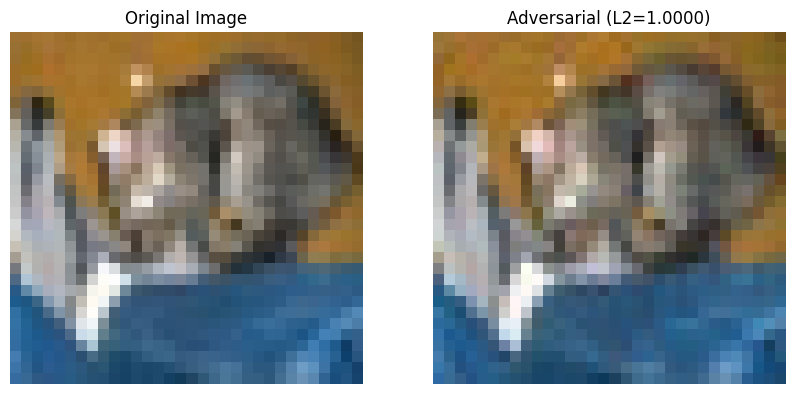

- Attack Time: 10054 ms
- Robust Acc: 0.0 / L2: 1.0 (10054 ms)


In [112]:
# 第一部分：Standard 模型攻击代码
import torch
import torchattacks
import matplotlib.pyplot as plt
from datetime import datetime

# 初始化结果存储
torchattacks_results_standard = {'acc': [], 'l2': [], 'step_acc': []}

# 处理 Standard 模型
model_name = 'Standard'
print('Model: {}'.format(model_name))
model = load_model(model_name, norm='Linf').to(device)

# 计算原始准确率
clean_acc = clean_accuracy(model, images, labels, device)
print(f"Clean Accuracy: {clean_acc}")

# 配置 CW 攻击参数
#atk = torchattacks.CW(model, c=1, kappa= 150, steps=50)

# 使用自定义攻击
atk = CustomCW(model, c=1, kappa=150, steps=50)
start = datetime.now()
# 执行攻击并记录每一步的准确率
attack_accuracies, l2_distances = attack_and_record(model, atk, images, labels, device)

adv_images = atk(images, labels)  # 获取最终对抗样本

# 反归一化（如果需要）
def denormalize(tensor):
    # 根据你的数据集调整均值和标准差
    mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).to(device)
    return tensor * std.view(1, 3, 1, 1) + mean.view(1, 3, 1, 1)

# 可视化对比原始图像和对抗样本
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(images[0].permute(1, 2, 0).cpu().detach().numpy())
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(adv_images[0].permute(1, 2, 0).cpu().detach().numpy())
plt.title(f"Adversarial (L2={l2_distances[-1]:.4f})")
plt.axis('off')
plt.show()
end = datetime.now()

print(f'- Attack Time: {int((end - start).total_seconds() * 1000)} ms')

acc = clean_accuracy(model, adv_images, labels, device)
l2 = l2_distance(model, images, adv_images, labels, device=device)
torchattacks_results_standard['acc'].append(acc)
torchattacks_results_standard['l2'].append(l2)
torchattacks_results_standard['step_acc'].append(attack_accuracies)

print('- Robust Acc: {} / L2: {:1.2} ({} ms)'.format(
    acc, l2, int((end - start).total_seconds() * 1000)
))


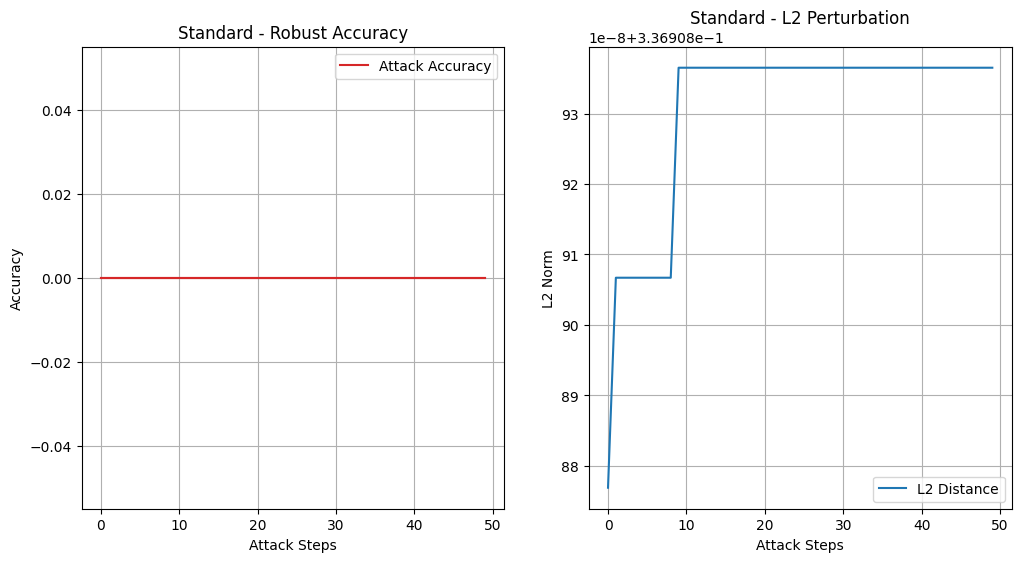

In [93]:
plot_attack_defense_curves(attack_accuracies, l2_distances, model_name)

Model: Wong2020Fast
Clean Accuracy: 1.0
Step 1: Accuracy=1.0000, L2=0.5542
Step 2: Accuracy=0.8000, L2=0.5954
Step 3: Accuracy=0.8000, L2=0.7034
Step 4: Accuracy=0.7000, L2=0.8086
Step 5: Accuracy=0.7000, L2=0.8211
Step 6: Accuracy=0.6000, L2=0.8269
Step 7: Accuracy=0.5000, L2=0.8321
Step 8: Accuracy=0.5000, L2=0.8458
Step 9: Accuracy=0.5000, L2=0.8561
Step 10: Accuracy=0.5000, L2=0.8587
Step 11: Accuracy=0.5000, L2=0.8567
Step 12: Accuracy=0.5000, L2=0.8536
Step 13: Accuracy=0.5000, L2=0.8535
Step 14: Accuracy=0.5000, L2=0.8555
Step 15: Accuracy=0.5000, L2=0.8571
Step 16: Accuracy=0.5000, L2=0.8583
Step 17: Accuracy=0.5000, L2=0.8607
Step 18: Accuracy=0.5000, L2=0.8649
Step 19: Accuracy=0.5000, L2=0.8696
Step 20: Accuracy=0.5000, L2=0.8737
Step 21: Accuracy=0.5000, L2=0.8696
Step 22: Accuracy=0.5000, L2=0.8641
Step 23: Accuracy=0.5000, L2=0.8599
Step 24: Accuracy=0.5000, L2=0.8560
Step 25: Accuracy=0.5000, L2=0.8561
Step 26: Accuracy=0.5000, L2=0.8580
Step 27: Accuracy=0.5000, L2=0.86

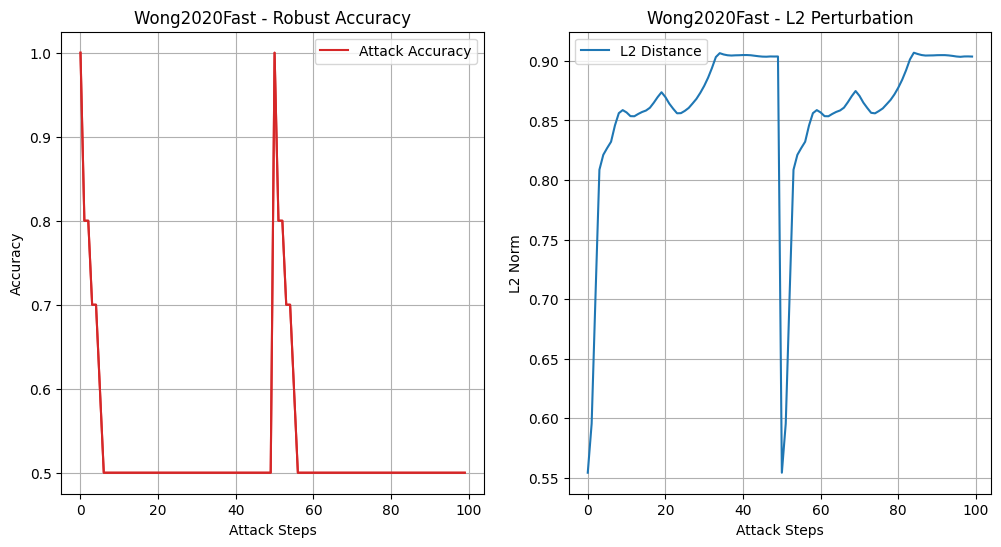

In [113]:
# CW 攻击代码
import torch
import torchattacks
import matplotlib.pyplot as plt
from datetime import datetime

# 初始化结果存储
torchattacks_results_wong = {'acc': [], 'l2': [], 'step_acc': []}

# 处理 Wong2020Fast 模型
model_name = 'Wong2020Fast'
print('Model: {}'.format(model_name))
model = load_model(model_name, norm='Linf').to(device)

# 计算原始准确率
clean_acc = clean_accuracy(model, images, labels, device)
print(f"Clean Accuracy: {clean_acc}")

# 配置 CW 攻击参数（关键优化）
atk = CustomCW(model, c=1, kappa=150, steps=50)

start = datetime.now()
# 执行攻击并记录每一步的准确率
attack_accuracies, l2_distances = attack_and_record(
    model, atk, images, labels, device
)
adv_images = atk(images, labels)  # 获取最终对抗样本
end = datetime.now()

print(f'- Attack Time: {int((end - start).total_seconds() * 1000)} ms')

acc = clean_accuracy(model, adv_images, labels, device)
l2 = l2_distance(model, images, adv_images, labels, device=device)
torchattacks_results_wong['acc'].append(acc)
torchattacks_results_wong['l2'].append(l2)
torchattacks_results_wong['step_acc'].append(attack_accuracies)

print('- Robust Acc: {} / L2: {:1.2} ({} ms)'.format(
    acc, l2, int((end - start).total_seconds() * 1000)
))

# 绘制准确率和L2曲线
plot_attack_defense_curves(attack_accuracies, l2_distances, model_name)

In [ ]:
# 第3部分：Rice2020overfitting 模型攻击代码
import torch
import torchattacks
import matplotlib.pyplot as plt
from datetime import datetime


# 初始化结果存储
torchattacks_results_wong = {'acc': [], 'l2': [], 'step_acc': []}

# 处理 Rice2020overfitting 模型
model_name = 'Rice2020Overfitting'
print('Model: {}'.format(model_name))
model = load_model(model_name, norm='Linf').to(device)

# 计算原始准确率
clean_acc = clean_accuracy(model, images, labels, device)
print(f"Clean Accuracy: {clean_acc}")

# 配置 CW 攻击参数
atk = CustomCW(model, c=1, kappa=150, steps=50)

start = datetime.now()
# 执行攻击并记录每一步的准确率
attack_accuracies = attack_and_record(model, atk, images, labels, device)
adv_images = atk(images, labels)  # 获取最终对抗样本
end = datetime.now()

print(f'- Attack Time: {int((end - start).total_seconds() * 1000)} ms')

acc = clean_accuracy(model, adv_images, labels, device)
l2 = l2_distance(model, images, adv_images, labels, device=device)
torchattacks_results_wong['acc'].append(acc)
torchattacks_results_wong['l2'].append(l2)
torchattacks_results_wong['step_acc'].append(attack_accuracies)

print('- Robust Acc: {} / L2: {:1.2} ({} ms)'.format(
    acc, l2, int((end - start).total_seconds() * 1000)
))


Model: Rice2020Overfitting
Clean Accuracy: 0.800000011920929
Step 1: Accuracy=0.8000, L2=0.5541
Step 2: Accuracy=0.8000, L2=0.5614
Step 3: Accuracy=0.7000, L2=0.6599
Step 4: Accuracy=0.7000, L2=0.7581
Step 5: Accuracy=0.7000, L2=0.7692
Step 6: Accuracy=0.7000, L2=0.7690
Step 7: Accuracy=0.6000, L2=0.7856
Step 8: Accuracy=0.5000, L2=0.8126
Step 9: Accuracy=0.5000, L2=0.8227
Step 10: Accuracy=0.5000, L2=0.8239
Step 11: Accuracy=0.4000, L2=0.8201
Step 12: Accuracy=0.4000, L2=0.8177
Step 13: Accuracy=0.4000, L2=0.8177
Step 14: Accuracy=0.4000, L2=0.8158
Step 15: Accuracy=0.4000, L2=0.8136
Step 16: Accuracy=0.4000, L2=0.8140
Step 17: Accuracy=0.4000, L2=0.8148
Step 18: Accuracy=0.4000, L2=0.8139
Step 19: Accuracy=0.4000, L2=0.8121
Step 20: Accuracy=0.4000, L2=0.8115
Step 21: Accuracy=0.4000, L2=0.8106
Step 22: Accuracy=0.4000, L2=0.8088
Step 23: Accuracy=0.4000, L2=0.8077
Step 24: Accuracy=0.4000, L2=0.8071
Step 25: Accuracy=0.4000, L2=0.8055
Step 26: Accuracy=0.4000, L2=0.8042
Step 27: Acc